# **Financial Information Retrieval for Opinion-Aware Document Ranking- MCO FINX**
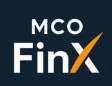

Bachelor in Artificial Intelligence

A.Y. 2025/2026

Authors : Marta Paniconi, Oliwia Iwanska, Chiara Pierini

-----------

# Downloading the collection

Using ir_datasets
Source: https://ir-datasets.com/beir.html#beir/fiqa

In [ ]:
!pip install python-terrier
!pip install pyterrier-dr

In [ ]:
import pyterrier as pt
from pyterrier_dr.sbert_models import SBertBiEncoder
from pyterrier_dr import FlexIndex
from tqdm import tqdm
import pandas as pd
import numpy as np
import re, os, json, shutil
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

### Persistent Storage for Offline Artifacts

We mount Google Drive to enable persistent storage in Colab.  
A `BASE_DIR` is defined to store offline precomputed artifacts (lexical index, SBERT embeddings), avoiding recomputation across sessions.  
This allows efficient reuse of indices and a lightweight online retrieval pipeline.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/IR_Project_FiQA"
os.makedirs(BASE_DIR, exist_ok=True)

-------------

# **1. Collection**

In [ ]:
dataset = pt.get_dataset('irds:beir/fiqa/test')

In [ ]:
for doc in dataset.get_corpus_iter():
    print(doc.keys())
    print(doc)
    break

[INFO] [starting] building docstore
[INFO] [starting] opening zip file
[INFO] If you have a local copy of https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/17918ed23cd04fb15047f73e6c3bd9d9
[INFO] [starting] https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip
docs_iter:   0%|                                     | 0/57638 [00:00<?, ?doc/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.0%| 0.00/17.9M [00:00<?, ?B/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.2%| 32.8k/17.9M [00:00<01:14, 241kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.5%| 81.9k/17.9M [00:00<01:00, 294kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 1.1%| 197k/17.9M [00:00<00:38, 466kB/s] 
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/dat

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

dict_keys(['text', 'docno'])
{'text': "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.", 'docno': '3'}


----------

# **2. Analysis of the collection**

In [ ]:
# Let us access some of the raw documents
for i, doc in enumerate(dataset.get_corpus_iter()):
    print(doc)
    if i == 9:
        break

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

{'text': "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.", 'docno': '3'}
{'text': "So nothing preventing false ratings besides additional scrutiny from the market/investors, but there are some newer controls in place to prevent institutions from using them. Under the DFA banks can no longer solely rely on credit ratings as due diligence to buy a financial instrument, so that's a plus. The intent being that if financial institutions do their own leg work then *maybe* they'll figure out that a certain CDO is garbage or not.  Edit: lead in", 'docno': '31'}
{'text': "You can never us

## 2.1 Raw count of documents and columns

In [ ]:
docs = list(dataset.get_corpus_iter())  # this loads all documents into memory
df = pd.DataFrame(docs)

print("Columns in df:", df.columns.tolist())
print("Number of documents:", len(df))

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

Columns in df: ['text', 'docno']
Number of documents: 57638


## 2.2 Check for missing or empty documents

In [ ]:
# A document is considered "missing" if text is NaN or only whitespace
df["is_missing"] = df["text"].isna() | (df["text"].astype(str).str.strip() == "")

missing_count = df["is_missing"].sum()
print("\nMissing or empty text documents count:", missing_count)
print("Proportion of missing documents:", missing_count / len(df))


Missing or empty text documents count: 38
Proportion of missing documents: 0.0006592872757555779


## 2.3 Compute a simple size measure based on text

In [ ]:
df["doc_text_size"] = df["text"].fillna("").apply(len)

print("\nSummary of document text sizes (character length):\n")
print(df["doc_text_size"].describe())

print("\nExamples:")
print("Smallest document size:", df["doc_text_size"].min())
print("Largest document size:", df["doc_text_size"].max())
print("Average document size:", df["doc_text_size"].mean())



Summary of document text sizes (character length):

count    57638.000000
mean       767.210816
std        738.614266
min          0.000000
25%        329.000000
50%        522.000000
75%        935.000000
max      16990.000000
Name: doc_text_size, dtype: float64

Examples:
Smallest document size: 0
Largest document size: 16990
Average document size: 767.2108157812554


## 2.4 Numeric content detection

Before choosing the retrieval strategy, we briefly investigated whether numeric information plays a central role in FiQA and a numeric-aware retrieval approach would be justified.


In [ ]:
num_re = re.compile(r"""
(?<!\w)                                   # left boundary (avoid inside words)
-?                                        # optional minus
(?:\d{1,3}(?:[.,]\d{3})+|\d+)             # 1,000 / 1.000 / 1000
(?:[.,]\d+)?                              # optional decimals
%?                                        # optional percent
(?!\w)                                    # right boundary
""", re.VERBOSE)

currency_re = re.compile(r"[$€£]")
digit_re = re.compile(r"\d")

def numeric_features(text):
    s = "" if text is None else str(text)

    nums = num_re.findall(s)
    n_tokens = max(1, len(s.split()))

    return pd.Series({
        "num_numbers": len(nums),                         # numeric expressions
        "num_digits": len(digit_re.findall(s)),           # raw digit count
        "num_percent": s.count("%"),                      # percent symbols
        "num_currency": len(currency_re.findall(s)),      # currency symbols
        "numeric_density": len(nums) / n_tokens           # numbers per token
    })

# Apply in one pass
num_feat = df["text"].apply(numeric_features)
df = pd.concat([df, num_feat], axis=1)

print("\nSummary of numeric content (absolute counts):\n")
print(df[["num_numbers", "num_digits", "num_percent", "num_currency"]].describe())

print("\nSummary of numeric density (ratio of numbers per token):\n")
print(df["numeric_density"].describe())

# How many docs have ANY numbers”
has_any_numbers = (df["num_numbers"] > 0).mean()
print(f"\nDocs with at least one numeric expression: {has_any_numbers:.3%}")



Summary of numeric content (absolute counts):

        num_numbers    num_digits   num_percent  num_currency
count  57638.000000  57638.000000  57638.000000  57638.000000
mean       2.170113      6.306187      0.398557      0.529390
std        4.749916     15.289154      1.318156      1.975639
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000
50%        0.000000      1.000000      0.000000      0.000000
75%        2.000000      6.000000      0.000000      0.000000
max      158.000000    924.000000     30.000000     48.000000

Summary of numeric density (ratio of numbers per token):

count    57638.000000
mean         0.015019
std          0.028372
min          0.000000
25%          0.000000
50%          0.000000
75%          0.020000
max          1.000000
Name: numeric_density, dtype: float64

Docs with at least one numeric expression: 46.551%


### Interpretation

Approximately 46.5% of the documents in FiQA contain at least one numeric expression.
However, numeric content remains extremely sparse across the collection.

The median numeric density is zero, and for 75% of the documents numeric expressions account for less than 2% of the tokens. This indicates that, even when present, numbers typically play a marginal role in the document content rather than structuring the information.

Only a small fraction of documents exhibits a high concentration of numeric expressions, corresponding to outliers such as tables, calculations, or highly technical explanations.

As a result, numeric-aware retrieval mechanisms (e.g., numeric reasoning or table-oriented retrieval) are unlikely to provide consistent benefits across most queries.

We therefore focus our retrieval design on lexical, semantic, and opinion-oriented signals, which better match the overall characteristics of the dataset.


----------------------

#**3. Indexing**

In [ ]:
if not pt.java.started():
    pt.init()

dataset = pt.get_dataset("irds:beir/fiqa/test")
# Lexical index path on Drive (persistent)
LEX_INDEX_PATH = f"{BASE_DIR}/fiqa-index"

# Build index only if it does not exist
if not os.path.exists(LEX_INDEX_PATH):
    print("Building lexical index (offline, one-time)...")

    indexer = pt.index.IterDictIndexer(
        LEX_INDEX_PATH,
        meta={"docno": 20},
        text_attrs=["text"]
    )
    indexref = indexer.index(dataset.get_corpus_iter())

    print("Lexical index built at:", LEX_INDEX_PATH)
else:
    print("Lexical index already exists. Reusing:", LEX_INDEX_PATH)

# Load index using IndexFactory
index = pt.IndexFactory.of(LEX_INDEX_PATH)

# Print collection statistics
stats = index.getCollectionStatistics()

print("Index folder:", LEX_INDEX_PATH)
print("Number of documents:", stats.getNumberOfDocuments())
print("Number of postings:", stats.getNumberOfPostings())
print("Number of tokens:", stats.getNumberOfTokens())
print("Number of unique terms:", stats.getNumberOfUniqueTerms())
print("Average document length:", stats.getAverageDocumentLength())

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
Building lexical index (offline, one-time)...


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipython-input-1188602489.py:2: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

14:54:03.337 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
14:54:21.379 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents
Lexical index built at: /content/drive/MyDrive/IR_Project_FiQA/fiqa-index
Index folder: /content/drive/MyDrive/IR_Project_FiQA/fiqa-index
Number of documents: 57638
Number of postings: 2714611
Number of tokens: 3783214
Number of unique terms: 51260
Average document length: 65.63749609632534


-----------------

# **4. Queries (The test set!)**

In [ ]:
queries = dataset.get_topics()
display(queries)

[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]
[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
...,...,...
643,4102,How can I determine if my rate of return is “g...
644,3566,Where can I buy stocks if I only want to inves...
645,94,Using credit card points to pay for tax deduct...
646,2551,How to find cheaper alternatives to a traditio...


The FiQA test set contains **648 queries**, each expressed as a natural-language question and associated with a unique query identifier.  
Most queries are formulated as complete questions rather than short keyword queries, reflecting complex and explanatory information needs typical of financial domains.


## 4.1 Identifying Opinion-Oriented Queries

To decide when sentiment-aware reranking may be beneficial, we perform a lightweight analysis of the queries.
We detect the presence of opinion, uncertainty, or sentiment-related cues using a small set of domain-specific keywords and expressions.

This analysis is not intended to provide a fine-grained sentiment classification, but to identify queries where evaluative or judgment-oriented intent is likely.

In [ ]:
sentiment_cues = {

    # explicit positive sentiment / evaluation
    "positive": [
        "good", "great", "better", "best", "strong", "bullish", "optimistic",
        "upside", "benefit", "gain", "advantage", "improve", "improvement",
        "growth", "opportunity", "confidence", "surge", "rise", "rally",
        "outperform", "beat", "exceed", "prosper", "favorable",
        "attractive", "promising", "solid", "healthy", "positive"
    ],

    # explicit negative sentiment / evaluation
    "negative": [
        "bad", "poor", "worse", "worst", "weak", "bearish", "pessimistic",
        "risk", "risky", "decline", "loss", "fall", "drop",
        "fear", "concern", "downside", "negative", "uncertain", "volatile",
        "danger", "bubble", "collapse", "default", "overvalued",
        "problem", "threat", "warning", "trouble", "slowdown"
    ],

    # subjective / opinion verbs
    "opinion_words": [
        "think", "believe", "feel", "opinion", "view", "consider",
        "assume", "judge", "expect", "hope", "doubt", "worry",
        "argue", "predict", "forecast", "estimate", "suspect",
        "perceive", "assess", "evaluate"
    ],

    # decision / advice / action intent
    "decision_words": [
        "buy", "sell", "hold", "invest", "investment", "trading",
        "trade", "short", "long", "enter", "exit", "allocate",
        "rebalance", "position", "bet", "speculate",
        "worth", "recommend", "suggest", "advice", "guidance",
        "rating", "upgrade", "downgrade"
    ],

    # valuation & pricing language
    "valuation_words": [
        "undervalued", "overvalued", "fair value", "intrinsic value",
        "price target", "target price", "valuation", "pricing",
        "cheap", "expensive", "priced in", "mispriced",
        "pe ratio", "p/e", "pb ratio", "p/b", "multiple",
        "earnings", "revenue", "profitability", "margin"
    ],

    # market / investor sentiment phrasing
    "market_reaction_phrases": [
        "market reaction", "investor reaction", "investor sentiment",
        "market sentiment", "market mood", "market view",
        "investors feel", "market feels", "market confidence",
        "market optimism", "market pessimism"
    ],

    # uncertainty, outlook, future expectations
    "uncertainty_phrases": [
        "should i", "should we", "is it worth", "is it safe",
        "is it risky", "is this risky", "is this safe",
        "worth buying", "worth investing", "worth holding",
        "good investment", "bad investment",
        "risk of", "chance of",
        "outlook", "future", "future outlook", "long term",
        "short term", "forecast", "expectations",
        "potential", "prospects",
        "viable", "sustainable"
    ],

    # comparison & ranking language (opinion without sentiment)
    "comparison_phrases": [
        "better than", "worse than", "best stock", "worst stock",
        "top pick", "top choice", "stronger than", "weaker than",
        "compared to", "vs", "versus", "relative to"
    ],

    # question-style opinion triggers
    "question_phrases": [
        "what do you think", "your thoughts", "your opinion",
        "is it a good", "is this a good",
        "is it time to", "is now a good time",
        "should i buy", "should i sell", "should i invest",
        "should i hold", "buy or sell"
    ],
}

single_word_cues = (
    sentiment_cues["positive"]
    + sentiment_cues["negative"]
    + sentiment_cues["opinion_words"]
    + sentiment_cues["decision_words"]
)

compiled_single_word = [
    re.compile(rf"\b{re.escape(w)}\b") for w in single_word_cues
]

phrase_cues = (
    sentiment_cues["market_reaction_phrases"]
    + sentiment_cues["uncertainty_phrases"]
    + sentiment_cues["valuation_words"]
    + sentiment_cues["comparison_phrases"]
    + sentiment_cues["question_phrases"]
)

def has_sentiment_cue(query: str) -> bool:
    """Return True if the query contains sentiment/opinion/uncertainty cues."""
    if query is None:
        return False
    text = str(query).lower()

    # phrase match first
    if any(p in text for p in phrase_cues):
        return True

    # word-boundary match for single tokens (reduces false positives like 'brisk' vs 'risk')
    return any(p.search(text) for p in compiled_single_word)

has_cue = queries["query"].apply(has_sentiment_cue)

cue_counts = has_cue.value_counts(dropna=False)
cue_perc = has_cue.value_counts(normalize=True, dropna=False) * 100

print("Sentiment / opinion cue flag counts:")
print(cue_counts)

print("\nSentiment / opinion cue flag percentages:")
print(cue_perc.round(2))

# Optional debug / sanity check (remove in final notebook)
display(
    pd.DataFrame({
        "qid": queries["qid"],
        "query": queries["query"],
        "has_sentiment_cue": has_cue
    }).head(10)
)


Sentiment / opinion cue flag counts:
query
False    411
True     237
Name: count, dtype: int64

Sentiment / opinion cue flag percentages:
query
False    63.43
True     36.57
Name: proportion, dtype: float64


,qid,query,has_sentiment_cue
0,4641,Where should I park my rainy-day / emergency f...,True
1,5503,Tax considerations for selling a property belo...,False
2,7803,Can the Delta be used to calculate the option ...,False
3,7017,Basic Algorithmic Trading Strategy,True
4,10152,What does a high operating margin but a small ...,True
5,3451,Should you keep your stocks if you are too lat...,True
6,4804,How do financial services aimed at women diffe...,False
7,7911,What is the difference between a 'trader' and ...,False
8,10809,Definitions of leverage and of leverage factor,False
9,6715,What does it mean if “IPOs - normally are sold...,False


### Interpretation

The lightweight cue-based analysis shows that **36.57%** of FiQA queries express sentiment, opinion, or uncertainty.
This confirms that evaluative intent is common but not dominant in the dataset. Consequently, sentiment is used selectively in our pipeline, where it can refine rankings without introducing noise for purely factual queries.



## 4.2 Query Preprocessing for Terrier Compatibility

Before applying any retrieval model, we perform a minimal query sanitisation step to avoid parser-related issues in Terrier. This step addresses technical compatibility only and does not aim to modify the information need expressed by the queries.


In [ ]:
def terrier_safe_query(q: str) -> str:
    q = str(q)
    # remove quotes that may break parsing
    q = q.replace('"', ' ')
    # replace single and double colons to avoid FIELD:term parsing
    q = q.replace("::", " ")
    q = q.replace(":", " ")
    # normalize whitespace
    q = re.sub(r"\s+", " ", q).strip()
    return q

queries_safe = queries.copy()
queries_safe["query"] = queries_safe["query"].apply(terrier_safe_query)

display(queries_safe.head(10))

,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
5,3451,Should you keep your stocks if you are too lat...
6,4804,How do financial services aimed at women diffe...
7,7911,What is the difference between a 'trader' and ...
8,10809,Definitions of leverage and of leverage factor
9,6715,What does it mean if “IPOs - normally are sold...


-----------------------

# **5. Qrels (The test set!)**

In [ ]:
qrels = dataset.get_qrels()

display(qrels)

,qid,docno,label,iteration
0,8,566392,1,0
1,8,65404,1,0
2,15,325273,1,0
3,18,88124,1,0
4,26,285255,1,0
...,...,...,...,...
1701,11039,330058,1,0
1702,11039,91183,1,0
1703,11054,155053,1,0
1704,11054,321015,1,0


The qrels define binary relevance judgements linking each query (`qid`) to relevant documents (`docno`), with `label = 1` indicating relevance.  



## 5.1 Distribution of Relevance Judgements per Query

Overall Statistics
count    648.000000
mean       2.632716
std        2.062616
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: docno, dtype: float64


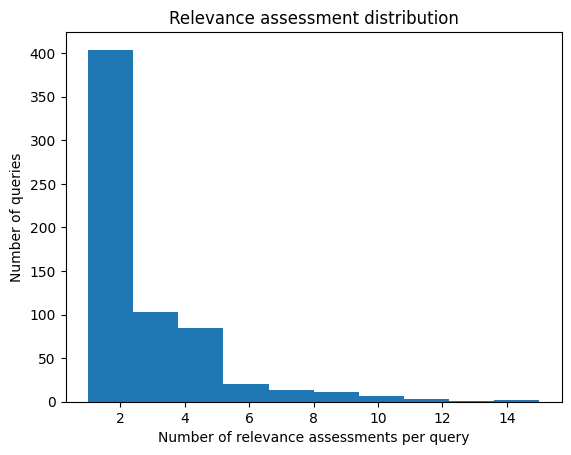

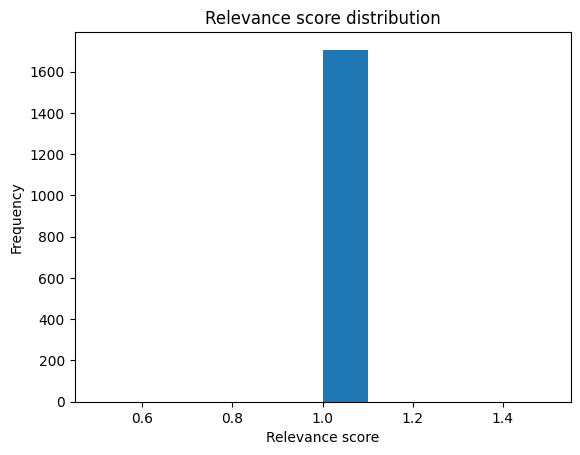

In [ ]:
# Count how many relevance assessments each query has
counts = qrels.groupby("qid")["docno"].count()  # group by query id and count documents
print("Overall Statistics")
print(counts.describe())  # show a summary of the count distribution

# Plot how many relevance assessments each query received
plt.figure()  # create a new figure
counts.plot(kind="hist")  # histogram showing distribution of judgment counts
plt.xlabel("Number of relevance assessments per query")  # label for x-axis
plt.ylabel("Number of queries")  # label for y-axis
plt.title("Relevance assessment distribution")  # title of the plot
plt.show()  # display the plot

# Show the queries with the highest number of relevance assessments
counts.sort_values(ascending=False).head()  # top queries by number of judgments

# Count how many times each relevance label occurs overall
qrels["label"].value_counts()  # distribution of relevance scores (e.g., 0, 1, 2, etc.)

# Plot the label distribution as a histogram
plt.figure()  # create a new figure
qrels["label"].plot(kind="hist")  # histogram of relevance labels
plt.xlabel("Relevance score")  # label for x-axis
plt.ylabel("Frequency")  # label for y-axis
plt.title("Relevance score distribution")  # title of the plot
plt.show()  # display the plot

### Interpretation

The distribution of relevance assessments shows that FiQA adopts a sparse relevance setting.  
On average, each query is associated with approximately **2–3 relevant documents**, with a median of 2. Most queries have only one or two relevant documents, while a small number of queries exhibit a higher number of relevance assessments, forming a long-tailed distribution.

FiQA relevance judgments are binary, with all relevant documents assigned the same label. While this simplifies evaluation, it makes retrieval more challenging, as the system must identify a small number of relevant documents among many non-relevant ones.


---------------------------------


# **6. Experiments**

## **6.1 Baseline Experiments**

## 6.1.1 BM25

BM25 is our simplest baseline and represents pure sparse lexical retrieval. It establishes a lower bound on performance based solely on keyword matching.

In [ ]:
indexref = pt.IndexRef.of(LEX_INDEX_PATH)
bm25 = pt.terrier.Retriever(indexref, wmodel="BM25")

# Check retrieval output for a small preview
results_sample = bm25.transform(queries_safe)
display(results_sample.head(20))

,qid,docid,docno,rank,score,query
0,4641,36224,376148,0,41.677305,Where should I park my rainy-day / emergency f...
1,4641,47916,497993,1,29.149791,Where should I park my rainy-day / emergency f...
2,4641,55690,580025,2,26.773005,Where should I park my rainy-day / emergency f...
3,4641,24501,253614,3,26.640181,Where should I park my rainy-day / emergency f...
4,4641,3157,32833,4,24.265187,Where should I park my rainy-day / emergency f...
5,4641,37155,386305,5,23.542073,Where should I park my rainy-day / emergency f...
6,4641,56072,583695,6,22.926576,Where should I park my rainy-day / emergency f...
7,4641,27375,282623,7,22.765005,Where should I park my rainy-day / emergency f...
8,4641,39987,416189,8,22.683605,Where should I park my rainy-day / emergency f...
9,4641,34580,358686,9,21.944761,Where should I park my rainy-day / emergency f...


### Retrieval effectivness evaluation

In [ ]:
experiment_results = pt.Experiment(
    [bm25],
    queries_safe,
    qrels,
    eval_metrics=[
        "P_1",
        "P_5",
        "P_10",
        "recall_5",
        "recall_10",
        "ndcg_cut_5",
        "ndcg_cut_10",
        "map"
    ],
    names = ["BM25"]
)

display(experiment_results)

,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.07037,0.247471,0.309708,0.23006,0.252589


### Interpretation

The BM25 baseline achieves reasonable early precision and ranking quality, indicating effective lexical matching of financial terms and entities. Recall improves at higher cutoffs, while precision decreases, reflecting the limits of term-based retrieval when relevance is sparse.

## 6.1.2 BM25 + RM3 query expansion

RM3 adds pseudo-relevance feedback, expanding the query using terms from top-ranked documents. This baseline tests whether query expansion alone can handle short and ambiguous FiQA queries.

### Retrieval pipeline

In [ ]:
retrieval_pipeline_bm25 = (pt.terrier.Retriever(indexref, wmodel="BM25"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(indexref, wmodel="BM25") >>
    pt.rewrite.RM3(indexref) >>
    pt.terrier.Retriever(indexref, wmodel="BM25")
)

### Retrieval effectiveness evaluation

In [ ]:
retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3],
    queries_safe,
    qrels,
    names=["BM25","BM25+RM3"],
    eval_metrics=[
        "P_1",
        "P_5",
        "P_10",
        "recall_5",
        "recall_10",
        "ndcg_cut_5",
        "ndcg_cut_10",
        "map"])

display(retrieval_effectiveness)

,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.23006,0.252589
1,BM25+RM3,0.206532,0.220679,0.107099,0.067593,0.243568,0.303302,0.22514,0.245375


### Interpretation

Query expansion with RM3 does not improve performance over the BM25 baseline. Across all metrics, effectiveness remains comparable or slightly worse, with minor drops in **MAP**, **precision**, and **nDCG**, while **recall** shows no meaningful gains.

This indicates that pseudo-relevance feedback introduces noise rather than useful signal for short and ambiguous financial queries.


## 6.1.3 BM25 + simple entity matching

This baseline introduces a simple entity overlap score based on company names or tickers, testing whether early entity-aware signals improve retrieval without deep semantics.

In [ ]:
TICKER_RE = re.compile(r"\b[A-Z]{1,5}\b")

COMPANY_GAZETTEER = {
    # Big Tech / Semis
    "apple","tesla","microsoft","amazon","google","alphabet","meta","nvidia","intel","amd","qualcomm","oracle","ibm","salesforce","adobe","paypal",
    # Consumer / Retail / Platforms
    "netflix","disney","uber","lyft","airbnb","shopify","walmart","target","costco",
    # Banks / Finance
    "jpmorgan","goldman","morgan","stanley","citigroup","citi","wells","bank","america","boa","barclays","hsbc","ubs","credit","suisse","deutsche","bnpparibas","santander",
    # Payments
    "visa","mastercard","amex","american","express","square","block","stripe",
    # Asset managers / Exchanges
    "blackrock","vanguard","fidelity","robinhood","coinbase","binance","nasdaq","nyse",
    # Energy / Industrials / Auto
    "exxon","chevron","shell","bp","boeing","ford","gm","ge","caterpillar",
    # Pharma
    "pfizer","moderna","johnson","merck",
    # Crypto
    "bitcoin","btc","ethereum","eth","solana","sol","ripple","xrp","dogecoin","doge","tether","usdt","usdc"
}

def extract_entities(query: str):
    q = "" if query is None else str(query)
    tickers = set(TICKER_RE.findall(q))
    qlow = q.lower()
    companies = {c for c in COMPANY_GAZETTEER if c in qlow}
    return tickers, companies

def entity_overlap(query: str, doc_text: str) -> float:
    tickers, companies = extract_entities(query)
    d = "" if doc_text is None else str(doc_text)

    # ticker match: exact uppercase token overlap
    doc_toks_upper = set(TICKER_RE.findall(d))
    ticker_matches = len(tickers & doc_toks_upper)

    # company match: case-insensitive substring
    dlow = d.lower()
    company_matches = sum(1 for c in companies if c in dlow)

    # tickers are usually more precise than names
    return 2.0 * ticker_matches + 1.0 * company_matches


### Reranking of the Top-K results

In [ ]:
TOPK = 100       # candidate set size is set to 100
LAMBDA = 0.5     # entity weight

pipe_entity = (
    bm25 % TOPK
    >> pt.text.get_text(dataset, "text")   # attach doc text needed by entity_overlap
    >> pt.apply.doc_score(
        lambda row: row["score"] + LAMBDA * entity_overlap(row["query"], row["text"])
    )
)

In [ ]:
systems = [bm25, pipe_entity]
names   = ["BM25", f"BM25 + EntityBoost (TOPK={TOPK}, λ={LAMBDA})"]

measures = ["P_1",
            "P_5",
            "P_10",
            "recall_5",
            "recall_10",
            "ndcg_cut_5",
            "ndcg_cut_10",
            "map"]

results_entity = pt.Experiment(
    systems,
    queries_safe,
    qrels,
    measures,
    names,
    perquery=False
)

display(results_entity)


,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
1,"BM25 + EntityBoost (TOPK=100, λ=0.5)",0.210495,0.237654,0.107099,0.069753,0.250104,0.310195,0.232265,0.253808


### Entity Boost Tuning

Entity-aware reranking modifies the BM25 score by adding a simple entity overlap signal:

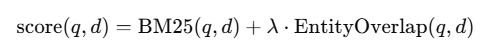

where `EntityOverlap(q,d)` captures shared company names and stock tickers between the query and the document.

The parameter λ controls the influence of the entity signal relative to BM25.  
We evaluate a small set of λ values to assess the sensitivity of retrieval performance, reranking the same top-K BM25 candidates in each case.


In [ ]:
lambdas = [0.1, 0.5, 1.0]

systems = [bm25]
names   = ["BM25"]

for lam in lambdas:
    pipe_lam = (
        bm25 % TOPK
        >> pt.text.get_text(dataset, "text")
        >> pt.apply.doc_score(
            lambda row, lam=lam: row["score"] + lam * entity_overlap(row["query"], row["text"])
        )
    )
    systems.append(pipe_lam)
    names.append(f"BM25+Entity(λ={lam})")

measures = [
    "P_1",
    "P_5",
    "P_10",
    "recall_5",
    "recall_10",
    "ndcg_cut_5",
    "ndcg_cut_10",
    "map"
]

results_entity_tune = pt.Experiment(
    systems,
    queries_safe,
    qrels,
    measures,
    names,
    perquery=False
)

display(results_entity_tune)


,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
1,BM25+Entity(λ=0.1),0.208715,0.237654,0.106173,0.069907,0.246699,0.308793,0.229809,0.252222
2,BM25+Entity(λ=0.5),0.210495,0.237654,0.107099,0.069753,0.250104,0.310195,0.232265,0.253808
3,BM25+Entity(λ=1.0),0.209692,0.237654,0.106173,0.070370,0.247532,0.311995,0.230880,0.254244


### Interpretation

* Very small values **(λ = 0.1)** slightly reduce overall effectiveness, indicating that a weak entity signal does not provide additional benefit.

* A moderate value **(λ = 0.5)** yields the best overall performance, with small but consistent improvements in recall and nDCG, suggesting a better balance between lexical relevance and entity matching.

* Larger values **(λ = 1.0)** do not further improve results and may partially offset the BM25 score, confirming that the entity signal should act as a complementary feature rather than a dominant ranking factor.

---------------

## **6.2 Additional Experiments**

# 6.2.1 E1 — Dense Semantic Retrieval (Bi-Encoder)

We now build a dense retriever that ranks documents by semantic similarity, not only by lexical overlap.

We separate:
- **Offline (indexing)**: compute and store document embeddings once (query-independent).
- **Online (retrieval)**: embed the query at runtime and retrieve nearest documents from the dense index.



## Offline Embedding Creation for the Documents

We use `FlexIndex` to build a dense index.  
During indexing, each document is encoded by SBERT and stored in the index.  
This is the expensive part, but it is **query-independent** and can be reused later.

In [ ]:
DENSE_INDEX_DIR = f"{BASE_DIR}/dense_index_sentenceBERT.flex"

# Initialize model and index handle
sentence_model = SBertBiEncoder("sentence-transformers/all-MiniLM-L6-v2")
dense_index = FlexIndex(DENSE_INDEX_DIR)

# Build the index ONLY if it does not already exist
if not os.path.exists(DENSE_INDEX_DIR):
    print("Building dense index (offline, one-time computation)...")

    offline_indexing_pipeline = sentence_model >> dense_index.indexer()
    offline_indexing_pipeline.index(dataset.get_corpus_iter())

    print("Dense index successfully built at:", DENSE_INDEX_DIR)
else:
    print("Dense index already exists. Loading from disk.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Building dense index (offline, one-time computation)...


beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

indexing: 0dvec [00:00, ?dvec/s]

Dense index successfully built at: /content/drive/MyDrive/IR_Project_FiQA/dense_index_sentenceBERT.flex


## Creating the Retrieval Pipeline (Online)

At runtime, the query is encoded with the same SBERT model and the system retrieves the most similar document vectors from the dense index.



In [ ]:
# online retrieval pipeline
retrieval_pipeline = sentence_model >> dense_index.retriever()

search_res = retrieval_pipeline.search("What does a high operating margin mean?")
display(search_res.head(10))


NumpyRetriever scoring:   0%|          | 0/15 [00:00<?, ?docbatch/s]

,qid,query,query_vec,docno,docid,score,rank
0,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",331606,32082,0.627405,0
1,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",545287,52423,0.621953,1
2,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",247680,23901,0.611323,2
3,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",104916,10183,0.605145,3
4,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",516797,49736,0.583154,4
5,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",113585,11017,0.562073,5
6,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",279185,27044,0.556657,6
7,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",469830,45136,0.544806,7
8,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",144431,14031,0.539289,8
9,1,What does a high operating margin mean?,"[0.04953161, -0.039160825, -0.03161119, 0.0034...",266900,25825,0.531718,9


## E1 evaluation

We run dense retrieval over all test queries and evaluate using the same IR metrics used for the rest of the project.

In [ ]:
dense_res_sentenceBERT = retrieval_pipeline.transform(queries_safe)
display(dense_res_sentenceBERT.head())


NumpyRetriever scoring:   0%|          | 0/15 [00:00<?, ?docbatch/s]

,qid,query,query_vec,docno,docid,score,rank
0,4641,Where should I park my rainy-day / emergency f...,"[0.10553603, 0.00030251054, 0.015367183, 0.044...",44594,4309,0.654813,0
1,4641,Where should I park my rainy-day / emergency f...,"[0.10553603, 0.00030251054, 0.015367183, 0.044...",254572,24607,0.647461,1
2,4641,Where should I park my rainy-day / emergency f...,"[0.10553603, 0.00030251054, 0.015367183, 0.044...",406219,39076,0.633527,2
3,4641,Where should I park my rainy-day / emergency f...,"[0.10553603, 0.00030251054, 0.015367183, 0.044...",438571,42126,0.613637,3
4,4641,Where should I park my rainy-day / emergency f...,"[0.10553603, 0.00030251054, 0.015367183, 0.044...",244408,23574,0.592019,4


In [ ]:

metrics = [
    "P_1","P_5","P_10",
    "recall_5","recall_10",
    "ndcg_cut_5","ndcg_cut_10",
    "map"
]

systems = [bm25, dense_res_sentenceBERT]
names   = ["BM25", "Dense Sentence-BERT"]

eval_dense = pt.Experiment(
    systems,
    queries_safe,
    qrels,
    metrics,
    names,
    perquery=False
)

display(eval_dense)

,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
1,Dense Sentence-BERT,0.312494,0.348765,0.167284,0.104475,0.366285,0.441306,0.345495,0.369442


###Interpretation
The Dense Sentence-BERT retriever consistently outperforms the BM25 baseline across all metrics.
Improvements in **MAP, precision, recall, and nDCG** indicate that dense semantic representations retrieve more relevant documents and rank them higher, especially at low cutoffs.
These results confirm that semantic matching effectively overcomes the limitations of purely lexical retrieval and motivates its use as a core component of the proposed hybrid approach.


## 6.2.2 E2 – Hybrid Retrieval: BM25 + Dense Semantics + Selective Sentiment Boost

##6.2.2.1 Pipeline Design
We design a **selective hybrid retrieval pipeline** that integrates lexical relevance, semantic similarity, and sentiment polarity, activating sentiment-aware reranking only when it is likely to add value.

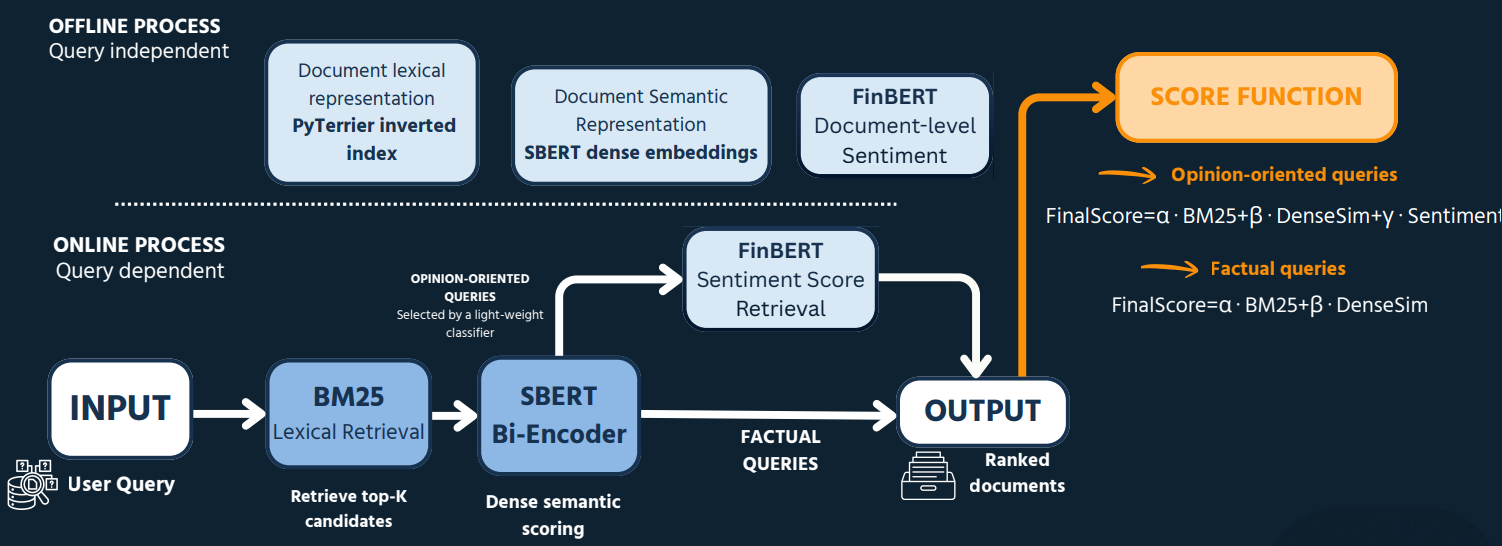

###- Pipeline Overview

The proposed E2 system consists of four stages:

1. **Lexical Retrieval (BM25)**  
   BM25 is used as a first-stage retriever to efficiently select a top-K set of candidate documents based on lexical overlap with the query.

2. **Dense Semantic Reranking (Sentence-BERT)**  
   The query and candidate documents are embedded into a shared dense vector space using a Sentence-BERT bi-encoder.  

3. **Selective Sentiment Analysis (FinBERT Classifier)**  
   A lightweight query analysis identifies whether a query is opinion-oriented.  
   Only for such queries, a FinBERT sentiment classifier is applied to the candidate documents to estimate sentiment polarity (positive, negative, neutral).  
   For factual queries, this step is skipped to avoid unnecessary computation and the introduction of noise.

4. **Score Combination and Final Ranking**  
   The final document score is computed by combining the available signals:
   - **Opinion queries**:
   $${FinalScore} = \alpha \cdot \text{BM25} + \beta \cdot \text{DenseSim} + \gamma \cdot \text{Sentiment}$$
   - **Factual queries**:
   $${FinalScore} = \alpha \cdot \text{BM25} + \beta \cdot \text{DenseSim}$$

   In this formulation, sentiment acts as a refinement signal rather than a dominant factor, influencing ranking only when aligned with the user’s intent.

###- Offline vs Online Design

*   **Offline**, we precompute query-independent resources, namely the dense document index and document-level sentiment scores.
*   **Online**, query-dependent components are executed: BM25 retrieval, dense semantic scoring, selective sentiment activation, and final score aggregation.

In [ ]:
queries_e2 = queries_safe.copy()
queries_e2["has_sentiment_cue"] = queries_e2["query"].apply(has_sentiment_cue)

In [ ]:
# FinBERT model for financial sentiment classification (neg/neu/pos)
FINBERT_MODEL = "ProsusAI/finbert"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL).to(device)
model = model.to(device)
model.eval()

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def finbert_scores_batched(texts, batch_size=16, max_length=512):
    """
    Offline doc-level sentiment feature computed with FinBERT.
    We use truncation for efficiency: score = P(pos) - P(neg).
    """
    scores = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)  # [neg, neu, pos]

        batch_scores = (probs[:, 2] - probs[:, 0]).detach().cpu().tolist()
        scores.extend(batch_scores)

    return scores

In [ ]:
SENT_PATH = f"{BASE_DIR}/finbert_doc_sentiment.parquet"

if os.path.exists(SENT_PATH):
    df_sent = pd.read_parquet(SENT_PATH)
    print(f"[LOAD] {SENT_PATH} ({len(df_sent)} docs)")
else:
    docnos, texts = [], []

    # Collect minimal fields to avoid keeping full doc objects in memory
    for doc in tqdm(dataset.get_corpus_iter(), desc="Loading corpus"):
        docnos.append(str(doc["docno"]))
        texts.append(doc.get("text", "") or "")

    # Compute offline feature once
    sent_scores = finbert_scores_batched(texts, batch_size=16, max_length=512)

    df_sent = pd.DataFrame({"docno": docnos, "finbert_sent": sent_scores})
    df_sent.to_parquet(SENT_PATH, index=False)

    print(f"[SAVE] {SENT_PATH} ({len(df_sent)} docs)")

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]


Loading corpus:  33%|███▎      | 19032/57638 [00:00<00:00, 190313.38it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


Loading corpus: 100%|██████████| 57638/57638 [00:00<00:00, 184770.62it/s]


[SAVE] /content/drive/MyDrive/IR_Project_FiQA/finbert_doc_sentiment.parquet (57638 docs)


We load the query-independent resources computed offline in previous steps:

- the **dense document index (FlexIndex)** built during E1,
- the **document-level sentiment cache** obtained with FinBERT.

In [ ]:
DENSE_INDEX_DIR = f"{BASE_DIR}/dense_index_sentenceBERT.flex"
DENSE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

dense_index = FlexIndex(DENSE_INDEX_DIR)
dense_model = SBertBiEncoder(DENSE_MODEL_NAME)

print(dense_model)

SBertBiEncoder('sentence-transformers/all-MiniLM-L6-v2')


### - Score Fusion and Sentiment Gating

BM25 and dense semantic scores are **min–max normalized** per query and combined in the final ranking.  
Document-level sentiment scores, precomputed offline with FinBERT, are added only for queries identified as opinion-oriented.  
For factual queries, sentiment is gated out, ensuring it refines rankings without introducing noise.

In [ ]:
TOPK  = 200
ALPHA = 0.5
BETA  = 1.5
GAMMA = 0.1   # keep small: sentiment is noisy if overweighted

# Build a fast lookup dict once (docno -> float)
doc_sent = dict(zip(df_sent["docno"].astype(str), df_sent["finbert_sent"].astype(float)))

# Utilities: robust per-query normalization
def _minmax_by_query(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Min-max normalize a score column within each query (qid).
    Safe for constant columns (mx == mn) -> returns 0.0 for all docs in that query.
    """
    g = df.groupby("qid", sort=False)[col]
    mn = g.transform("min")
    mx = g.transform("max")
    denom = (mx - mn).replace(0.0, 1.0)  # avoid division by zero
    return (df[col] - mn) / denom

# Main transformer: add sentiment + fuse scores
def add_sentiment_and_fuse(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input df must contain at least: qid, docno, bm25_score, dense_score, has_sentiment_cue
    Output adds: sent_score, bm25_n, dense_n, final_score, and overwrites 'score'
    """
    df = df.copy()

    # Ensure required cols exist
    required = ["qid", "docno", "bm25_score", "dense_score", "has_sentiment_cue"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"add_sentiment_and_fuse: missing columns {missing}")

    # Add offline sentiment by docno lookup
    # Note: sentiment is doc-level; if missing -> 0.0
    docno_str = df["docno"].astype(str)
    df["sent_score"] = docno_str.map(doc_sent).fillna(0.0).astype("float32")

    # Normalize BM25 and dense scores per query for fair fusion
    df["bm25_score"]  = df["bm25_score"].astype("float32")
    df["dense_score"] = df["dense_score"].astype("float32")

    df["bm25_n"]  = _minmax_by_query(df, "bm25_score").astype("float32")
    df["dense_n"] = _minmax_by_query(df, "dense_score").astype("float32")

    # Clip to [0,1] to guard numerical artifacts
    df["bm25_n"]  = df["bm25_n"].clip(0.0, 1.0)
    df["dense_n"] = df["dense_n"].clip(0.0, 1.0)

    # Gate sentiment: only if query has sentiment cue
    gate = df["has_sentiment_cue"].astype("int8")

    #  Final score computation
    df["final_score"] = (
        (ALPHA * df["bm25_n"]) +
        (BETA  * df["dense_n"]) +
        (GAMMA * gate * df["sent_score"])
    ).astype("float32")

    # PyTerrier ranks by 'score'
    df["score"] = df["final_score"]

    return df

###- Pipeline Instantiation and Preview

In [ ]:
pipe_e2 = (
    (bm25 % TOPK)
    >> pt.apply.generic(lambda df: df.rename(columns={"score": "bm25_score"}))
    >> dense_model
    >> dense_index.scorer()
    >> pt.apply.generic(lambda df: df.rename(columns={"score": "dense_score"}))
    >> pt.apply.generic(add_sentiment_and_fuse)
)

In [ ]:
res_e2_preview = pipe_e2.transform(queries_e2.head(5))
display(res_e2_preview[["qid","docno","bm25_score","dense_score", "has_sentiment_cue", "sent_score","score","rank"]].head(10))

  0%|          | 0/5 [00:00<?, ?it/s]

,qid,docno,bm25_score,dense_score,has_sentiment_cue,sent_score,score,rank
801,10152,113585,44.838303,0.818031,True,-0.025824,1.952100,0
802,10152,371515,44.382408,0.751541,True,0.818357,1.915956,1
800,10152,549181,47.974815,0.733440,True,0.721329,1.927129,2
804,10152,37032,27.739073,0.559814,True,0.809969,1.345992,3
849,10152,516797,17.108381,0.545007,True,0.794697,1.165485,4
811,10152,557350,21.723217,0.512775,True,0.727111,1.170153,5
971,10152,368738,13.732102,0.478084,True,0.638967,0.986413,6
975,10152,328017,13.712742,0.471126,True,0.390419,0.949351,7
806,10152,248342,23.095671,0.468920,True,0.883957,1.130493,8
816,10152,552281,19.829117,0.466579,True,-0.082448,0.982643,9


##6.2.2.2 Final Evaluation and Comparison

In [ ]:
metrics = ["P_1","P_5","P_10","recall_5","recall_10","ndcg_cut_5","ndcg_cut_10","map"]

systems = [bm25, retrieval_pipeline_rm3, pipe_entity, pipe_e2]
names   = ["BM25", "BM25+RM3", "BM25 + EntityBoost (TOPK=100, λ=0.5)", "E2 Hybrid: BM25@100 + Dense (SBERT) + FinBERT Sentiment (gated)"]

results = pt.Experiment(
    systems,
    queries_e2,
    qrels,
    eval_metrics=metrics,
    names=names,
    perquery=False,
    validate="ignore"
)

display(results)


  0%|          | 0/648 [00:00<?, ?it/s]

,name,map,P_1,P_5,P_10,recall_5,recall_10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
1,BM25+RM3,0.206532,0.220679,0.107099,0.067593,0.243568,0.303302,0.225140,0.245375
2,"BM25 + EntityBoost (TOPK=100, λ=0.5)",0.210495,0.237654,0.107099,0.069753,0.250104,0.310195,0.232265,0.253808
3,E2 Hybrid: BM25@100 + Dense (SBERT) + FinBERT ...,0.322441,0.370370,0.169444,0.104167,0.377535,0.448816,0.361309,0.383887


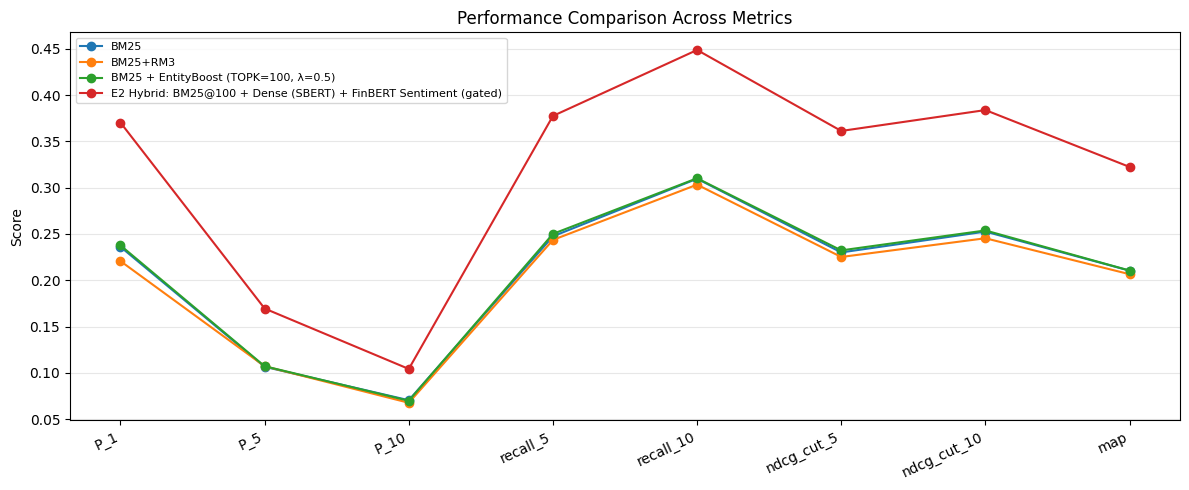

In [ ]:


metrics_order = ["P_1","P_5","P_10","recall_5","recall_10","ndcg_cut_5","ndcg_cut_10","map"]

df = results.copy()
plot_df = df.set_index("name")[metrics_order].T

plt.figure(figsize=(12, 5))

for system_name in plot_df.columns:
    plt.plot(plot_df.index, plot_df[system_name], marker="o", label=system_name)

plt.xticks(rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Performance Comparison Across Metrics")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation

The final E2 hybrid experiment is clearly successful, achieving substantial improvements over all baselines across every evaluation metric.

The combination of BM25 and dense semantic retrieval significantly increases recall and MAP, indicating that more relevant documents are retrieved and ranked higher.

Precision and nDCG also improve consistently, especially at low cutoffs, showing that relevant documents are pushed toward the top of the ranking.

The selective integration of sentiment further refines results for opinion-oriented queries, contributing to ranking quality without introducing noise.

**Overall, the gains confirm that the hybrid, query-aware design effectively addresses the limitations of purely lexical retrieval.**

-----------

# Final Conclusion




Across all experiments, purely lexical enhancements such as query expansion and lightweight entity matching provide limited or marginal improvements, highlighting their sensitivity to noise in short financial queries.

Dense semantic retrieval emerges as the main driver of effectiveness, substantially outperforming BM25-based baselines. Building on this, the final hybrid pipeline combines lexical, semantic, and selectively applied sentiment signals to achieve the best overall performance.